# Decomposition

## Global Importation

In [16]:
# Shape modules 
from collections import defaultdict

# Computational modules 
%matplotlib inline
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

## Global Inset

### Load Decomposition Results

In [17]:
path_decomp_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Decomposition'
filename = 'time_merged.nc'

save_names = ['swl3p0_decomposition_results', 'swl4p0_decomposition_results',
              'swl5p0_decomposition_results', 'swl6p0_decomposition_results']

names = ['3-degree warming', '4-degree warming', '5-degree warming', '6-degree warming']
decomposed_compiled_results = {scenario: {} for scenario in names}

for file, scenario in zip(tqdm(save_names), names):
    results_open = xr.open_dataset(f"{path_decomp_files}/{file}.nc")
    decomposed_compiled_results[scenario] = results_open

100%|████████████████████████████████████████████| 4/4 [00:00<00:00, 15.69it/s]


### Load Student-t Results

In [18]:
var_list = ['delta_precip', 'thermodynamic', 'dynamic', 'cross_term']

path_pval_3deg_files = []
path_pval_4deg_files = []
path_pval_5deg_files = []
path_pval_6deg_files = []

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[0]}/{names[0]}_{variable}_pvalues.nc'
    path_pval_3deg_files.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[1]}/{names[1]}_{variable}_pvalues.nc'
    path_pval_4deg_files.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[2]}/{names[2]}_{variable}_pvalues.nc'
    path_pval_5deg_files.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[3]}/{names[3]}_{variable}_pvalues.nc'
    path_pval_6deg_files.append(temp_path)

In [19]:
p_vals_compiled_results_3deg = {variable: {} for variable in var_list}
p_vals_compiled_results_4deg = {variable: {} for variable in var_list}
p_vals_compiled_results_5deg = {variable: {} for variable in var_list}
p_vals_compiled_results_6deg = {variable: {} for variable in var_list}

for (file, variable)  in zip(tqdm(path_pval_3deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_3deg[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_4deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_4deg[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_5deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_5deg[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_6deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_6deg[variable] = ds

100%|████████████████████████████████████████████| 4/4 [00:00<00:00, 73.66it/s]


### Standardise Coordinates

In [20]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

### Compute Monthly Average Over Time

In [21]:
# We are doing this (again) because we only saved the student t-test values.
# But not for anomalies.

all_months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

anomaly_decomp_ds = {scenario: {} for scenario in names}

for scenario in names:
    decomp_ds = decomposed_compiled_results[scenario][var_list]
    all_ds = standardise_coordinates(decomp_ds)

    # Get all available years.
    years = np.unique(all_ds.time.dt.year.values)
    first_100yrs = years[:100]
    last_100yrs = years[-100:]

    # Select first and last years
    first_100 = all_ds.where(all_ds.time.dt.year.isin(first_100yrs), drop=True)
    last_100 = all_ds.where(all_ds.time.dt.year.isin(last_100yrs), drop=True)

    # Calculate anomaly for each variable
    for variable in var_list:
        # Mean of last 100 years minus mean of first 100 years
        anomaly_decomp_ds[scenario][variable] = last_100[variable].mean('time') - first_100[variable].mean('time')

## Results Review

### Implementation (Plot)

In [23]:
# The input for decompose_data is the dataset corresponding to the senario input.
# Data input is the last 100 and first 100 years anomaly.
def decompose_results_map(decompose_data, scenario, lonmin, lonmax, latmin, latmax,
                          vmin_clim, vmax_clim, levels_clim,
                          vmin_decomp, vmax_decomp, levels_decomp,
                          vmin_cross, vmax_cross, levels_cross,
                          save, filename, sup_title, pval_dict):
    
    # Set up figure.
    fig, axes = plt.subplots(2, 2, figsize=(20, 10), 
                             subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True)

    fig.subplots_adjust(wspace=0.05, hspace=1.20)
    
    axes = axes.flatten()

    # Define variables of interest.
    # Cross term is deliberately excluded because it is very small.
    plot_variables = ['delta_precip', 'cross_term', 'thermodynamic', 'dynamic', ]

    # Title for the three columns.
    column_titles = ['Δ Precipitation', 'Cross Term (Nonlinear Interaction)',
                     'Thermodynamic Contribution', 'Dynamic Contribution']

    # Plot for each four decomposition components.
    for i, (variable, column_title) in enumerate(zip(plot_variables, column_titles)):

        data = decompose_data[variable]

        if 'lon' in data.coords:
            data = data.rename({'lon': 'longitude'})
        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})
    
        lon_orig = data['longitude'].values
        lat = data['latitude'].values

        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=-1)
        lon2d, lat2d = np.meshgrid(lon_cyclic, lat)
            
        # Define different colour palettes for each term.
        if variable == 'delta_precip':
            vmin = vmin_clim
            vmax = vmax_clim
            levels = levels_clim
            cmap = 'Blues'

        # Define different colour palettes for each term.
        elif variable == 'cross_term':
            vmin = vmin_cross
            vmax = vmax_cross
            levels = levels_cross
            cmap = 'BrBG'

        # Thermodynamic and dyanmic maps should use the same colour palette.
        # To directly compare their roles to the precipitation pattern.
        else:
            vmin = vmin_decomp
            vmax = vmax_decomp
            levels = levels_decomp
            cmap = 'RdBu'

        # Filled contours
        contour = axes[i].contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=cmap, extend='neither',
                                      transform=ccrs.PlateCarree())
        mm = axes[i].pcolormesh(lon2d, lat2d, data_cyclic, vmin=vmin, vmax=vmax,
                                   transform=ccrs.PlateCarree(), cmap=cmap)

        # Significance stippling
        if pval_dict[variable] is not None:
            sig_mask = pval_dict[variable]['p_value'].values <= 0.05
            hatch_mask = np.where(sig_mask, 1, np.nan)
            axes[i].pcolor(lon2d, lat2d, hatch_mask, hatch='..', alpha=0.0, zorder=3)
        
        # Formatting
        axes[i].set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
        axes[i].coastlines()
        axes[i].gridlines(draw_labels=True)
        axes[i].set_title(column_title, fontsize=16)

    # Colourbars
    # Delta Precip
    cbar_precip = fig.colorbar(axes[0].collections[0], ax=axes[0], orientation='horizontal',
                               fraction=0.08, pad=0.03)
    cbar_precip.set_label('ΔP (mm/day)', fontsize=14)

    # Cross Term
    cbar_decomp = fig.colorbar(axes[1].collections[0], ax=axes[1], orientation='horizontal',
                               fraction=0.08, pad=0.03)
    cbar_decomp.set_label('Nonlinear Interaction (mm/day)', fontsize=14)

    # Colourbar shared by thermodynamic and dynamic terms
    cbar_decomp = fig.colorbar(axes[3].collections[0], ax=axes[2:], orientation='horizontal',
                               fraction=0.08, pad=0.03)
    cbar_decomp.set_label('Precipitation Contribution (mm/day)', fontsize=14)
    
    fig.suptitle(sup_title, fontsize=20)

    if save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

### Resultant Figure A (World View)

In [24]:
vmin_clim, vmax_clim = 0, 1
levels_clim = np.arange(vmin_clim, vmax_clim, 0.01)

vmin_decomp, vmax_decomp = -0.35, 0.35
levels_decomp = np.arange(vmin_decomp, vmax_decomp, 0.01)

vmin_cross, vmax_cross = -0.05, 0.05
levels_cross = np.arange(vmin_cross, vmax_cross, 0.001)

lonmin, lonmax = -180, 180
latmin, latmax = -90, 90

save = True
save_path = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'

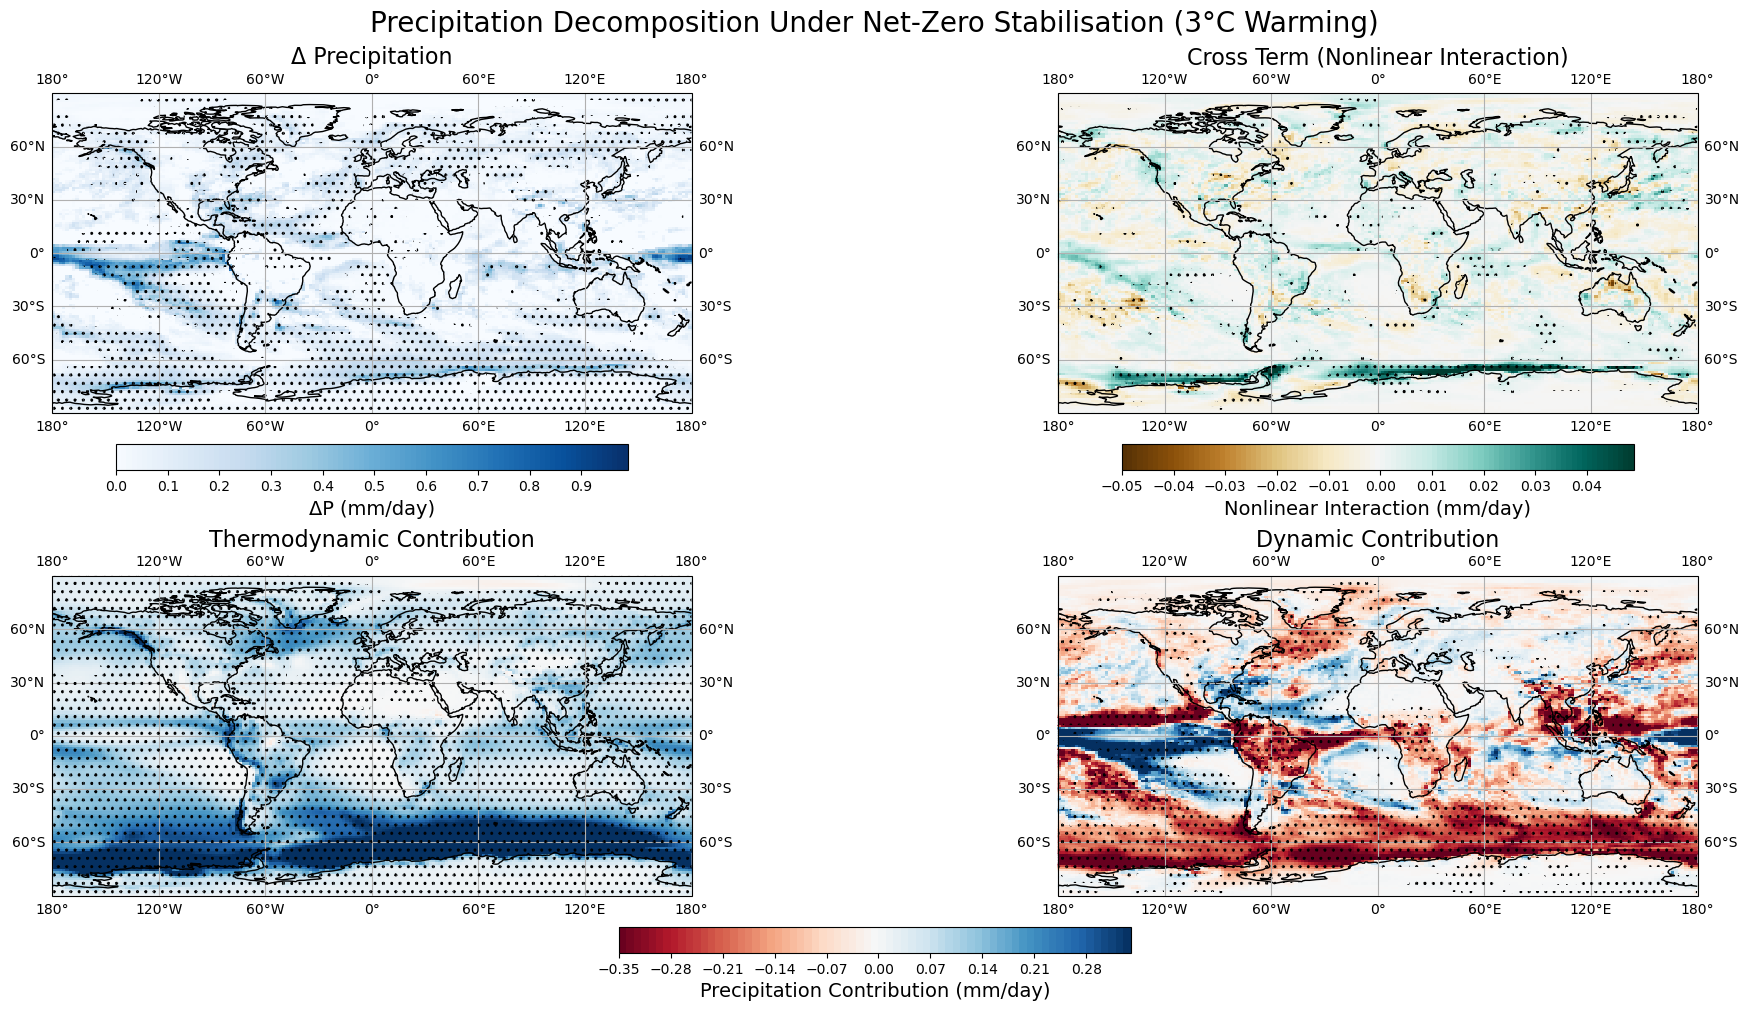

In [25]:
# This usually takes a while to load since it is handling very large datasets...
decomp_3_deg = anomaly_decomp_ds[names[0]]
scenario_3_deg = '3°C Warming'
filename_3_deg = f'{save_path}/decomposition_net-zero_maps_3-deg.png'
sup_title_3_deg = f'Precipitation Decomposition Under Net-Zero Stabilisation ({scenario_3_deg})'

decompose_results_map(decomp_3_deg, scenario_3_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_3_deg, sup_title_3_deg, p_vals_compiled_results_3deg)

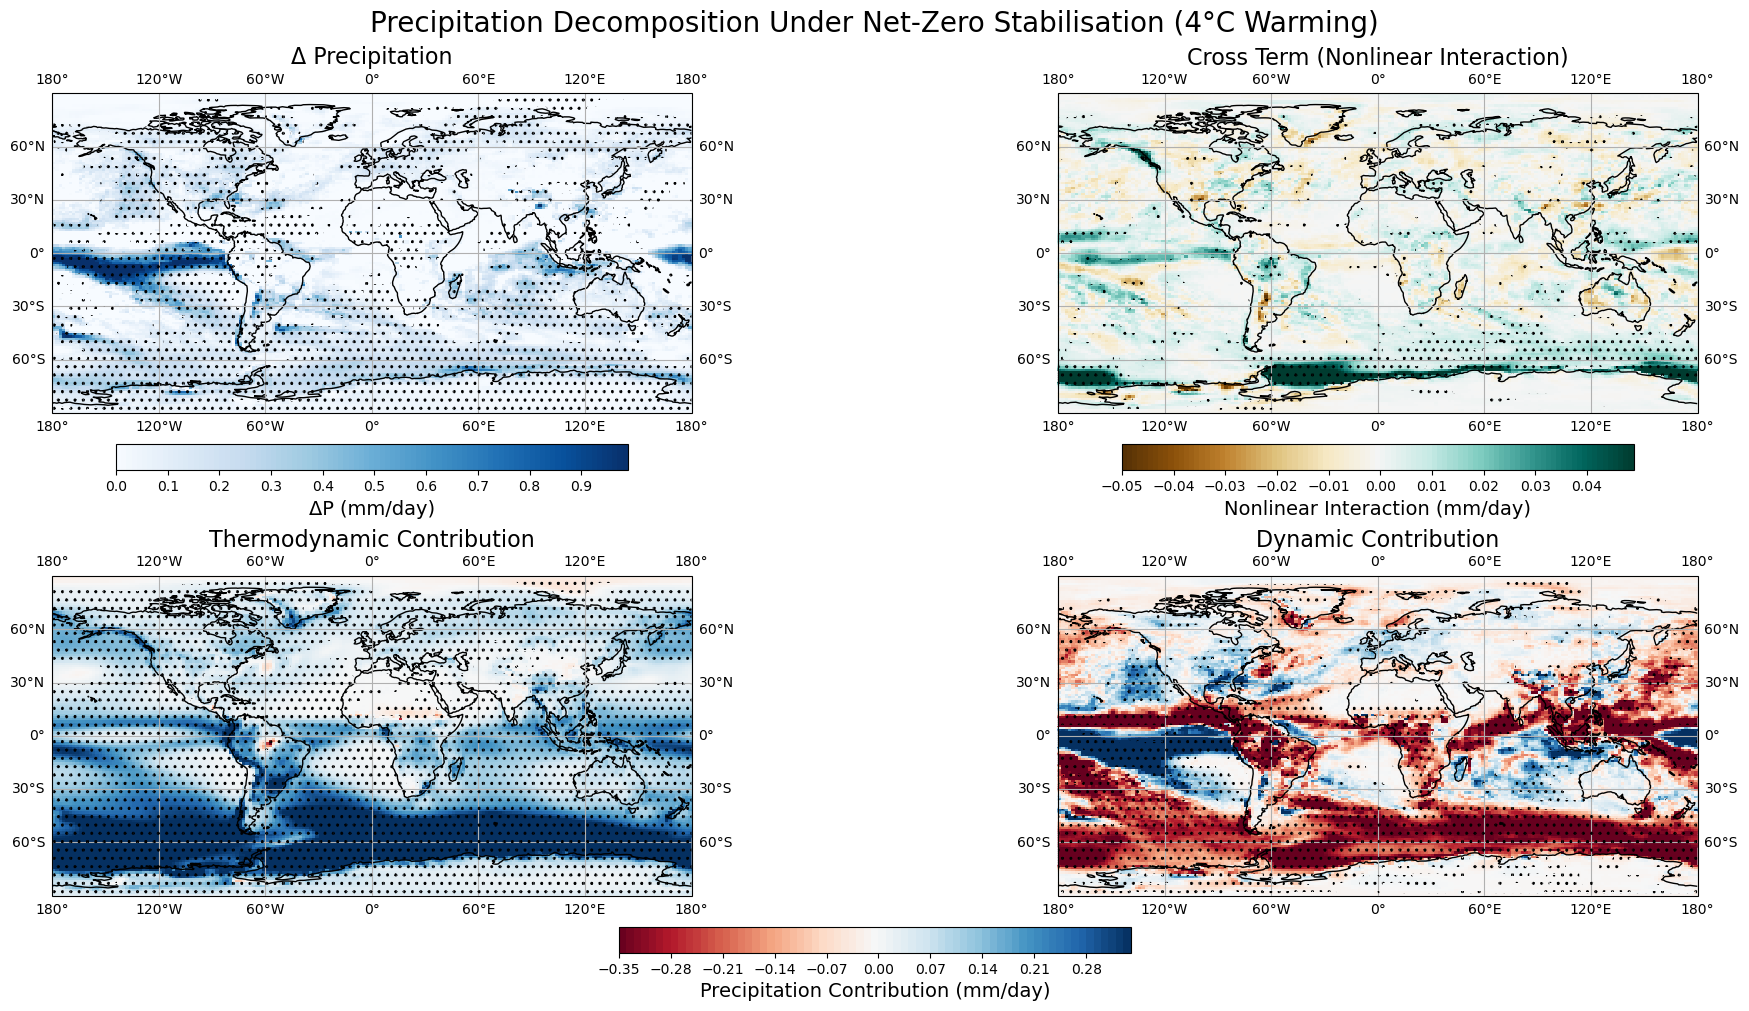

In [26]:
filename_4_deg = f'{save_path}/decomposition_net-zero_maps_4-deg.png'
decomp_4_deg = anomaly_decomp_ds[names[1]]
scenario_4_deg = '4°C Warming'
sup_title_4_deg = f'Precipitation Decomposition Under Net-Zero Stabilisation ({scenario_4_deg})'

decompose_results_map(decomp_4_deg, scenario_4_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_4_deg, sup_title_4_deg, p_vals_compiled_results_4deg)

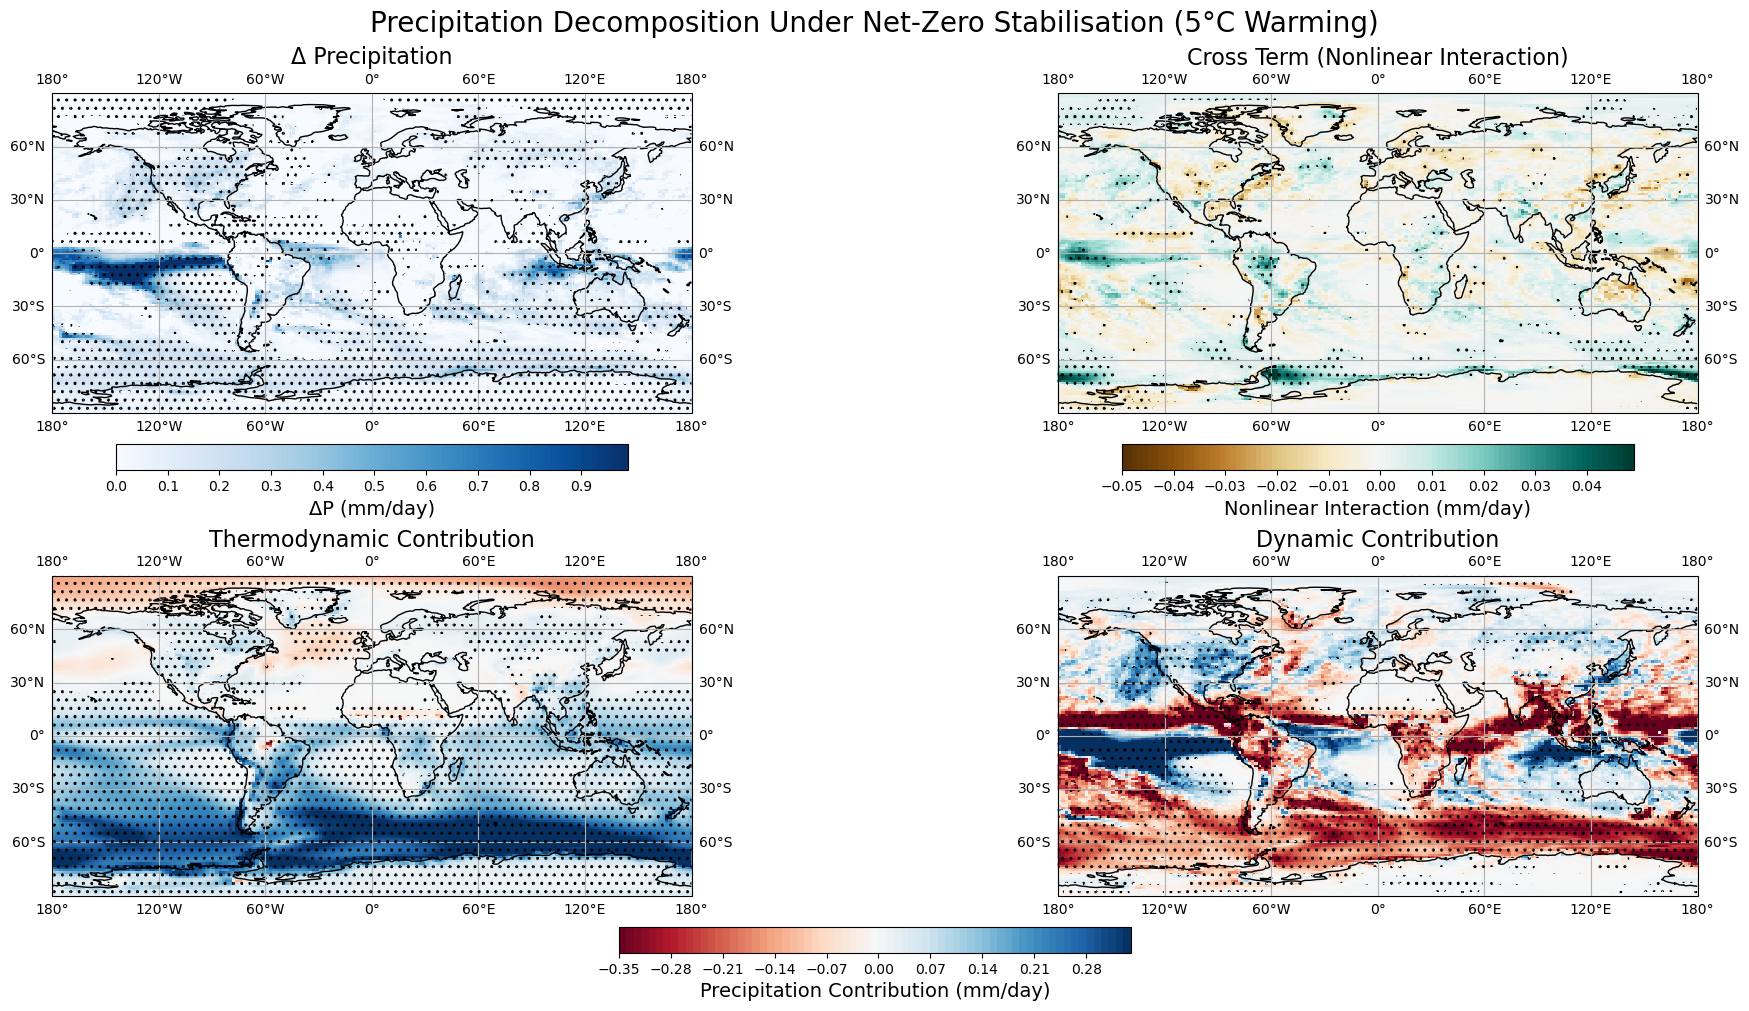

In [27]:
filename_5_deg = f'{save_path}/decomposition_net-zero_maps_5-deg.png'
decomp_5_deg = anomaly_decomp_ds[names[2]]
scenario_5_deg = '5°C Warming'
sup_title_5_deg = f'Precipitation Decomposition Under Net-Zero Stabilisation ({scenario_5_deg})'

decompose_results_map(decomp_5_deg, scenario_5_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_5_deg, sup_title_5_deg, p_vals_compiled_results_5deg)

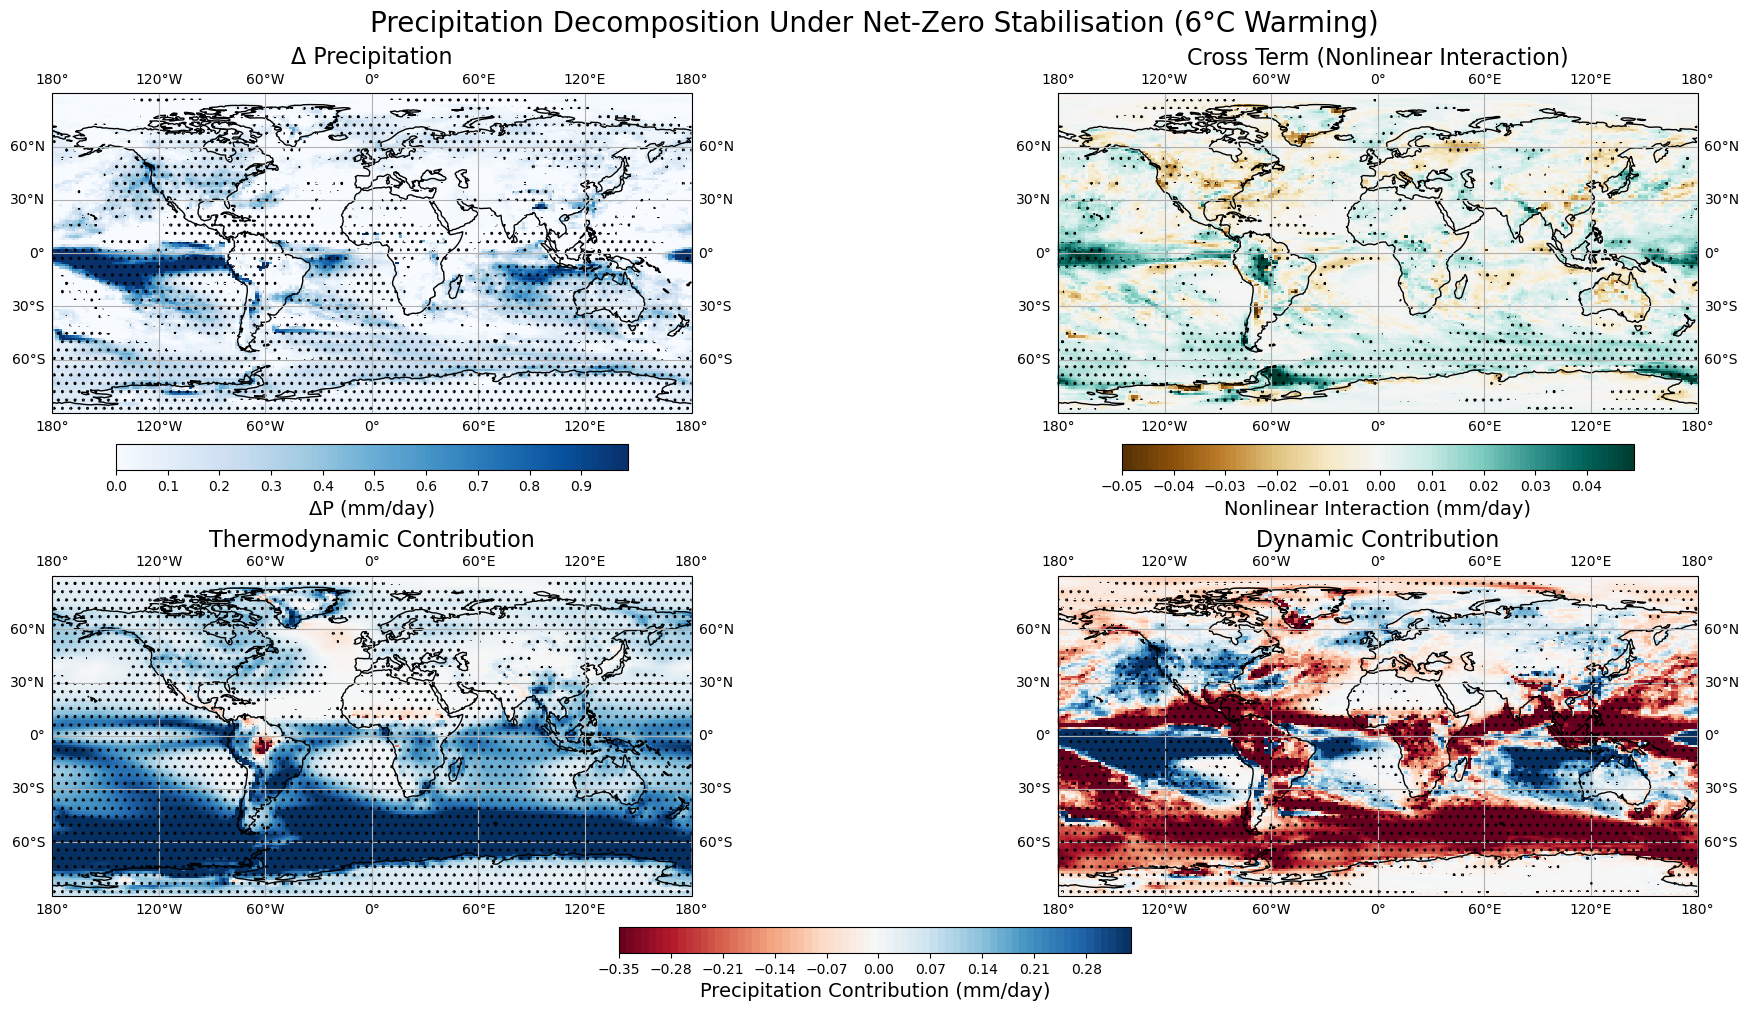

In [28]:
filename_6_deg = f'{save_path}/decomposition_net-zero_maps_6-deg.png'
decomp_6_deg = anomaly_decomp_ds[names[3]]
scenario_6_deg = '6°C Warming'
sup_title_6_deg = f'Precipitation Decomposition Under Net-Zero Stabilisation ({scenario_6_deg})'

decompose_results_map(decomp_6_deg, scenario_6_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_6_deg, sup_title_6_deg, p_vals_compiled_results_6deg)

### Resultant Figure B (Atlantic, Western Europe-Africa)

In [32]:
vmin_clim, vmax_clim = 0, 1
levels_clim = np.arange(vmin_clim, vmax_clim, 0.01)

vmin_decomp, vmax_decomp = -0.35, 0.35
levels_decomp = np.arange(vmin_decomp, vmax_decomp, 0.01)

vmin_cross, vmax_cross = -0.05, 0.05
levels_cross = np.arange(vmin_cross, vmax_cross, 0.001)

lonmin, lonmax = -60, 40
latmin, latmax = -20, 60

save = True
save_path = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'

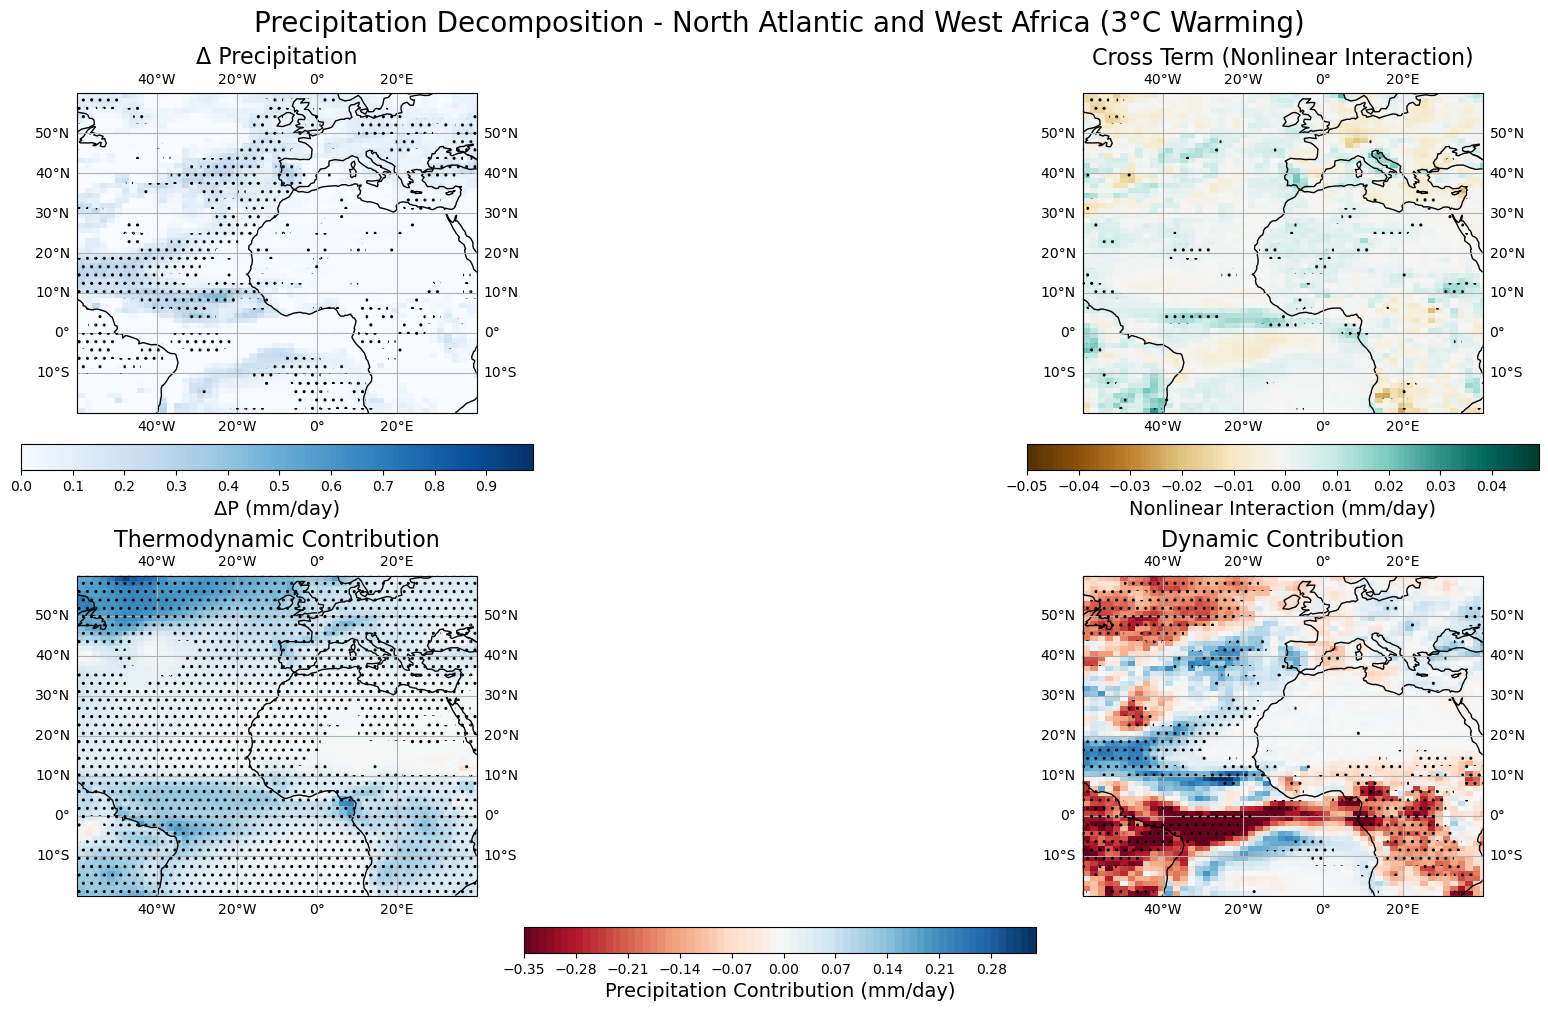

In [33]:
decomp_3_deg_atl = anomaly_decomp_ds[names[0]]
scenario_3_deg = '3°C Warming'
filename_3_deg_atl = f'{save_path}/decomposition_net-zero_maps_3-deg_zoomed_atlantic_africa.png'
sup_title_3_atl = f'Precipitation Decomposition - North Atlantic and West Africa ({scenario_3_deg})'

decompose_results_map(decomp_3_deg, scenario_3_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_3_deg_atl, sup_title_3_atl, p_vals_compiled_results_3deg)

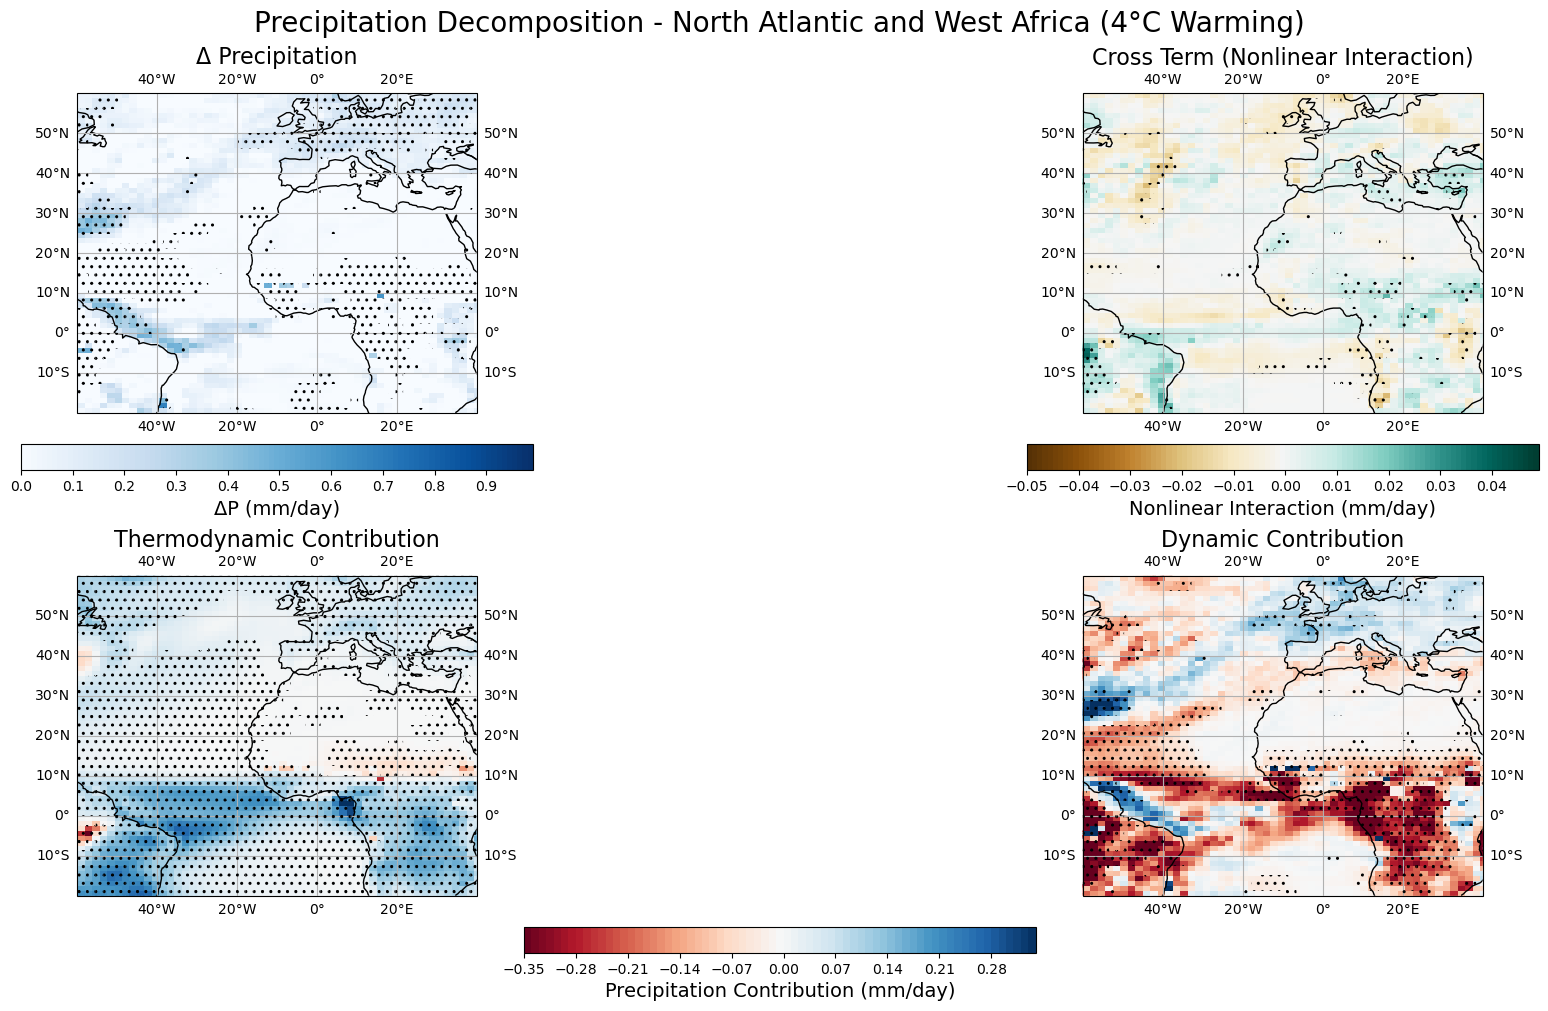

In [34]:
decomp_4_deg_atl = anomaly_decomp_ds[names[1]]
scenario_4_deg = '4°C Warming'
filename_4_deg_atl = f'{save_path}/decomposition_net-zero_maps_4-deg_zoomed_atlantic_africa.png'
sup_title_4_atl = f'Precipitation Decomposition - North Atlantic and West Africa ({scenario_4_deg})'

decompose_results_map(decomp_4_deg, scenario_4_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_4_deg_atl, sup_title_4_atl, p_vals_compiled_results_4deg)

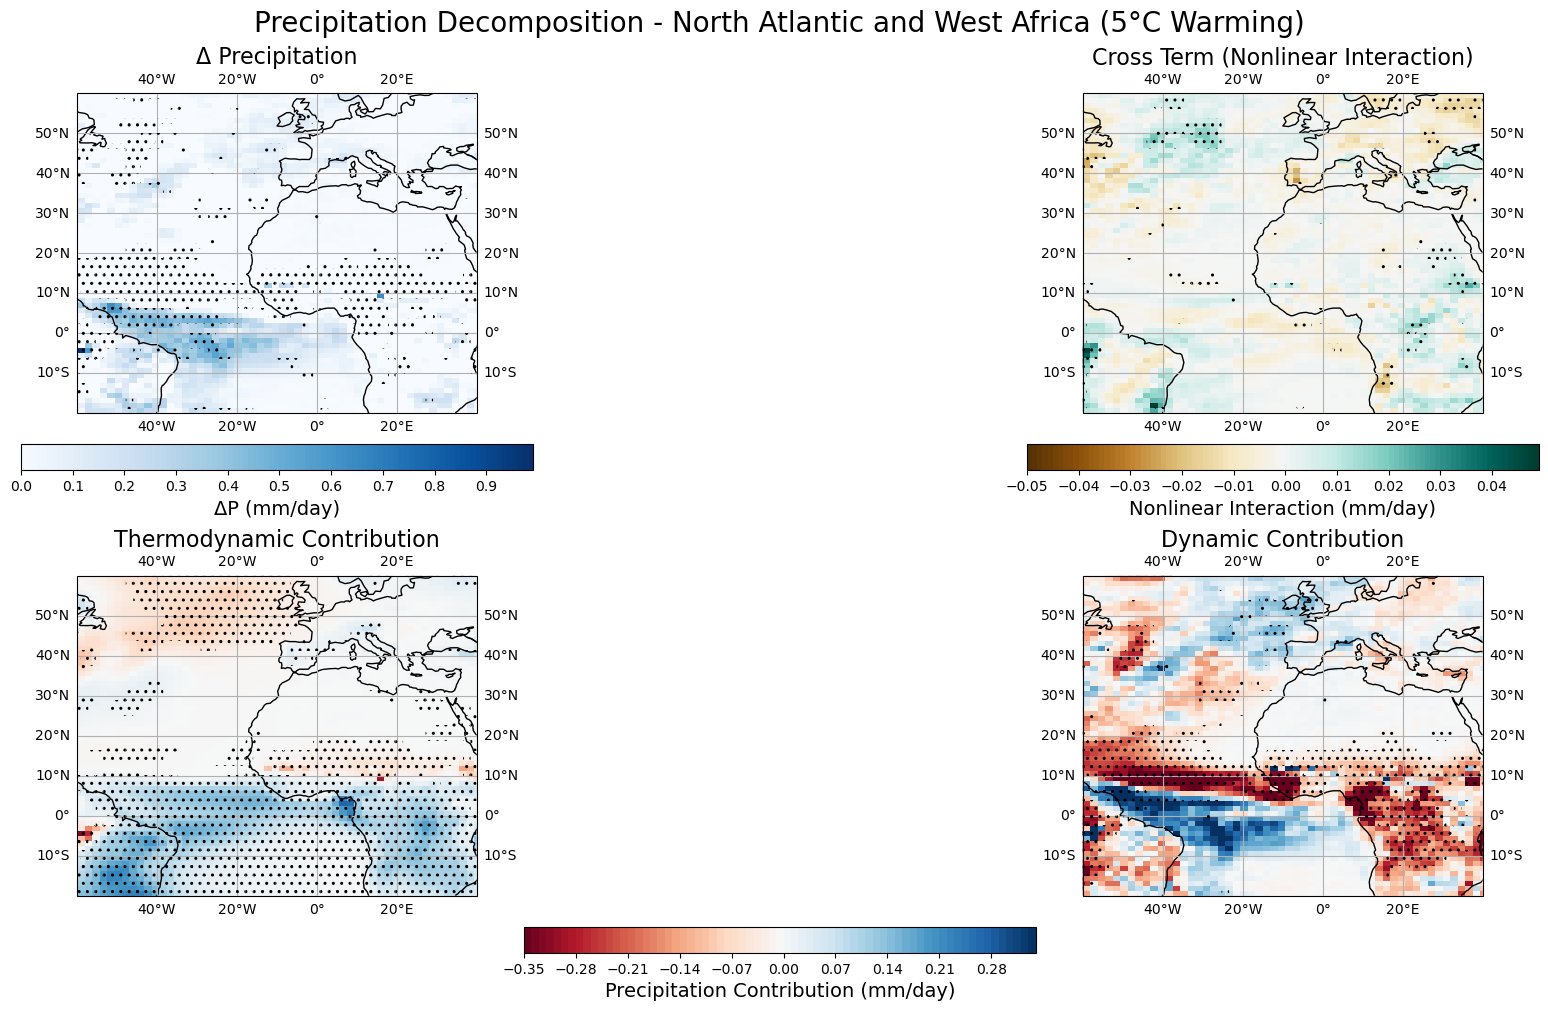

In [35]:
decomp_5_deg_atl = anomaly_decomp_ds[names[2]]
scenario_5_deg = '5°C Warming'
filename_5_deg_atl = f'{save_path}/decomposition_net-zero_maps_5-deg_zoomed_atlantic_africa.png'
sup_title_5_atl = f'Precipitation Decomposition - North Atlantic and West Africa ({scenario_5_deg})'

decompose_results_map(decomp_5_deg, scenario_5_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_5_deg_atl, sup_title_5_atl, p_vals_compiled_results_5deg)

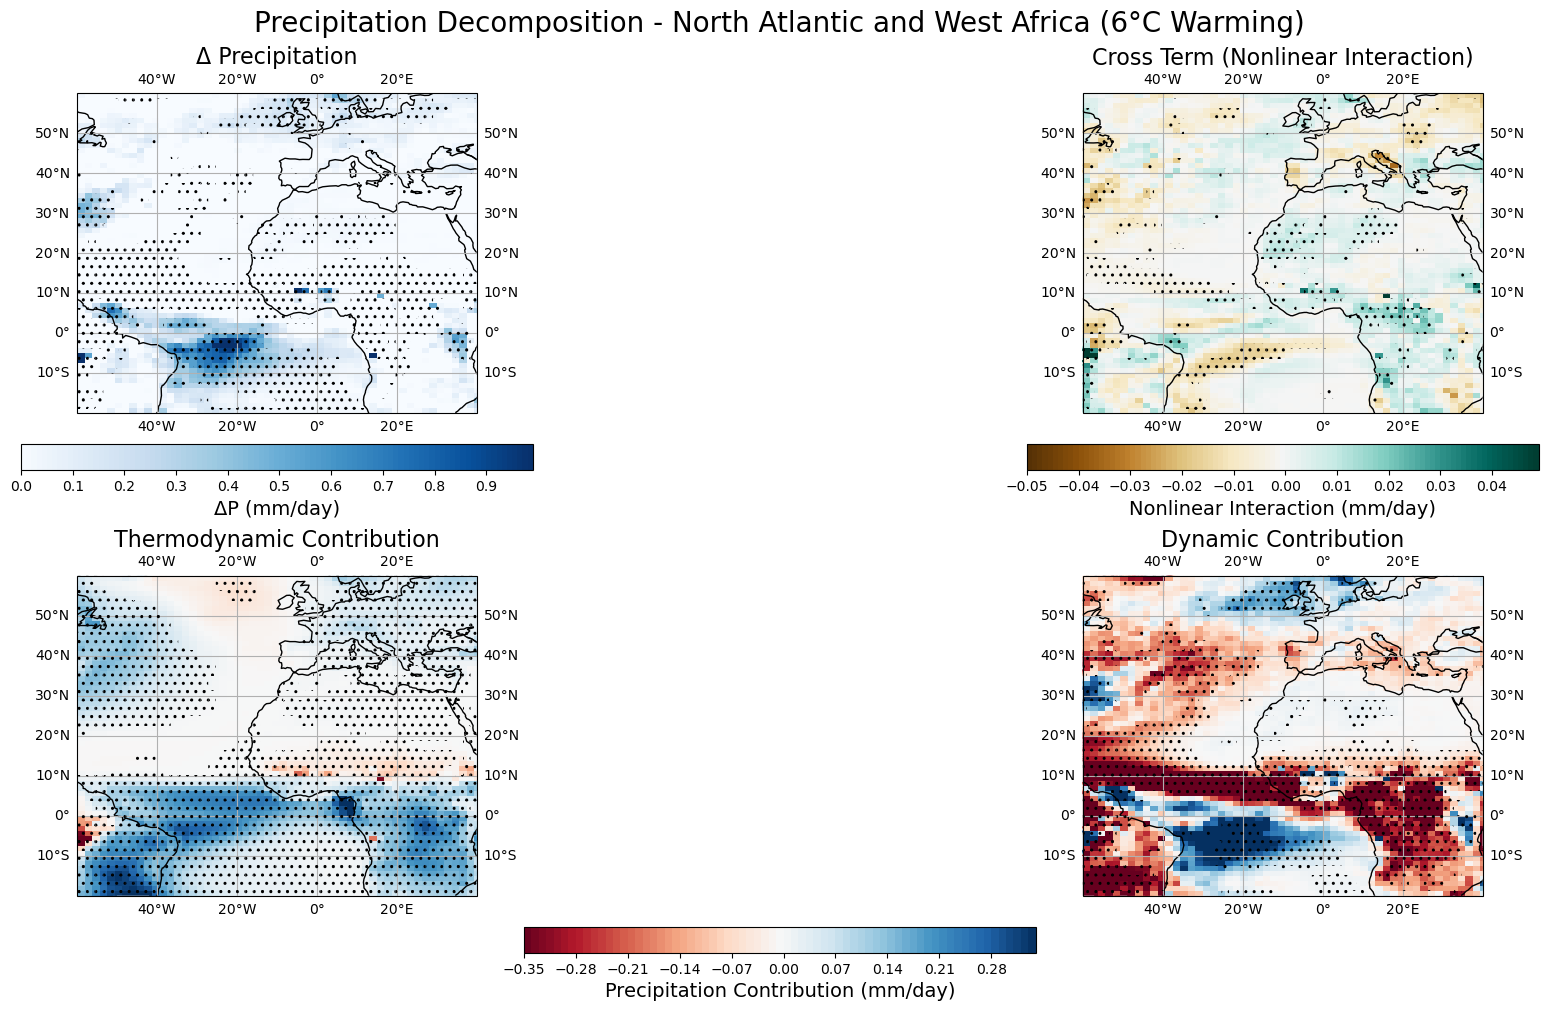

In [36]:
decomp_6_deg_atl = anomaly_decomp_ds[names[3]]
scenario_6_deg = '6°C Warming'
filename_6_deg_atl = f'{save_path}/decomposition_net-zero_maps_6-deg_zoomed_atlantic_africa.png'
sup_title_6_atl = f'Precipitation Decomposition - North Atlantic and West Africa ({scenario_6_deg})'

decompose_results_map(decomp_6_deg, scenario_6_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_6_deg_atl, sup_title_6_atl, p_vals_compiled_results_6deg)

### Animation

In [44]:
import imageio

overview_image_paths = [f'{save_path}/decomposition_net-zero_maps_3-deg.png',
                        f'{save_path}/decomposition_net-zero_maps_4-deg.png',
                        f'{save_path}/decomposition_net-zero_maps_5-deg.png',
                        f'{save_path}/decomposition_net-zero_maps_6-deg.png']

frames = []

for path in overview_image_paths:
    # Read the image.
    img = imageio.imread(path)
    frames.append(img)

# Save as GIF
output_path = f'{save_path}/decomposition_overview_compare.gif'
imageio.mimsave(output_path, frames, duration=3000, loop=0, quality=10)

In [46]:
zoomed_image_paths = [f'{save_path}/decomposition_net-zero_maps_3-deg_zoomed_atlantic_africa.png',
                      f'{save_path}/decomposition_net-zero_maps_4-deg_zoomed_atlantic_africa.png',
                      f'{save_path}/decomposition_net-zero_maps_5-deg_zoomed_atlantic_africa.png',
                      f'{save_path}/decomposition_net-zero_maps_6-deg_zoomed_atlantic_africa.png']

frames = []

for path in zoomed_image_paths:
    # Read the image.
    img = imageio.imread(path)
    frames.append(img)

# Save as GIF
output_path = f'{save_path}/decomposition_zoomed_compare.gif'
imageio.mimsave(output_path, frames, duration=3000, loop=0, quality=10)